# Theta power and movement

This notebook plots the theta time-frequency spetrogram and movement trajectory to check alignment of neural and behavioral data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.signal import ShortTimeFFT
from scipy.ndimage import gaussian_filter1d
import os

In [2]:
DATA_DIR = r"\\research-cifs.nyumc.org\research\buzsakilab\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106"
SESSION_NAME = "pre_sleep_g0"
PROBE = 3
CHANNEL = 163
START = 4_500 # in seconds
STOP = 5_000

In [3]:
session_name = os.path.basename(DATA_DIR)
print(f"Processing session: {session_name}")
dat_file = os.path.join(DATA_DIR, f"{session_name}_imec{PROBE}.lfp")
xml_file = os.path.join(DATA_DIR, f"{session_name}_imec{PROBE}.xml")

#getting number of channels from xml
import xml.etree.ElementTree as ET
tree = ET.parse(xml_file)
root = tree.getroot()
nChannels = int(root.find('acquisitionSystem').find('nChannels').text)


print(f"Number of channels: {nChannels}")


# loading the dat file
sampling_rate = 1250
data = np.memmap(dat_file, dtype='int16', mode='r')
data = data.reshape(-1, nChannels)
channel_data = data[START * sampling_rate:STOP * sampling_rate, CHANNEL]  # Convert to microvolts
print(f"Loaded data shape: {channel_data.shape}")


Processing session: Bilat_R02_20251106
Number of channels: 385
Loaded data shape: (625000,)


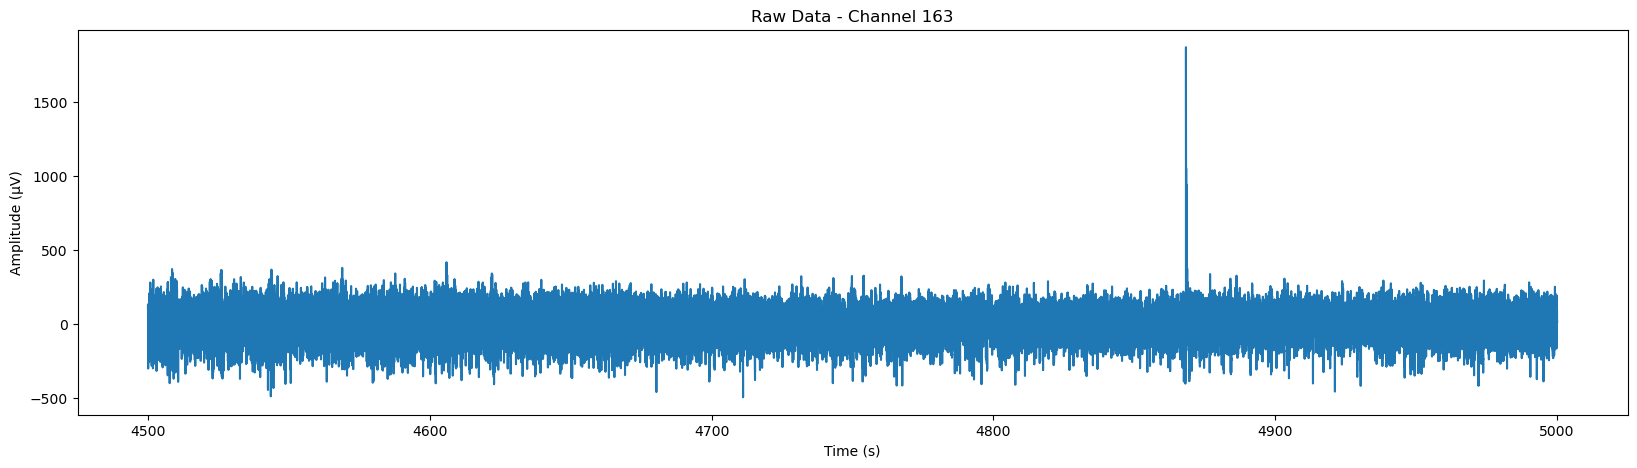

In [4]:
sampling_rate = 1250  # Hz
times = np.arange(channel_data.shape[0]) / sampling_rate
times = times + START

# plotting the raw data for the selected channel
plt.figure(figsize=(20, 5))
plt.plot(times, channel_data)
plt.title(f"Raw Data - Channel {CHANNEL}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.show()


Number of TTLs: 240196
Number of frames: 308232
Trimming frames from 308232 to 240196
Tracking start time: 3913.393 s, end time: 6495.247 s, duration: 2581.854 s


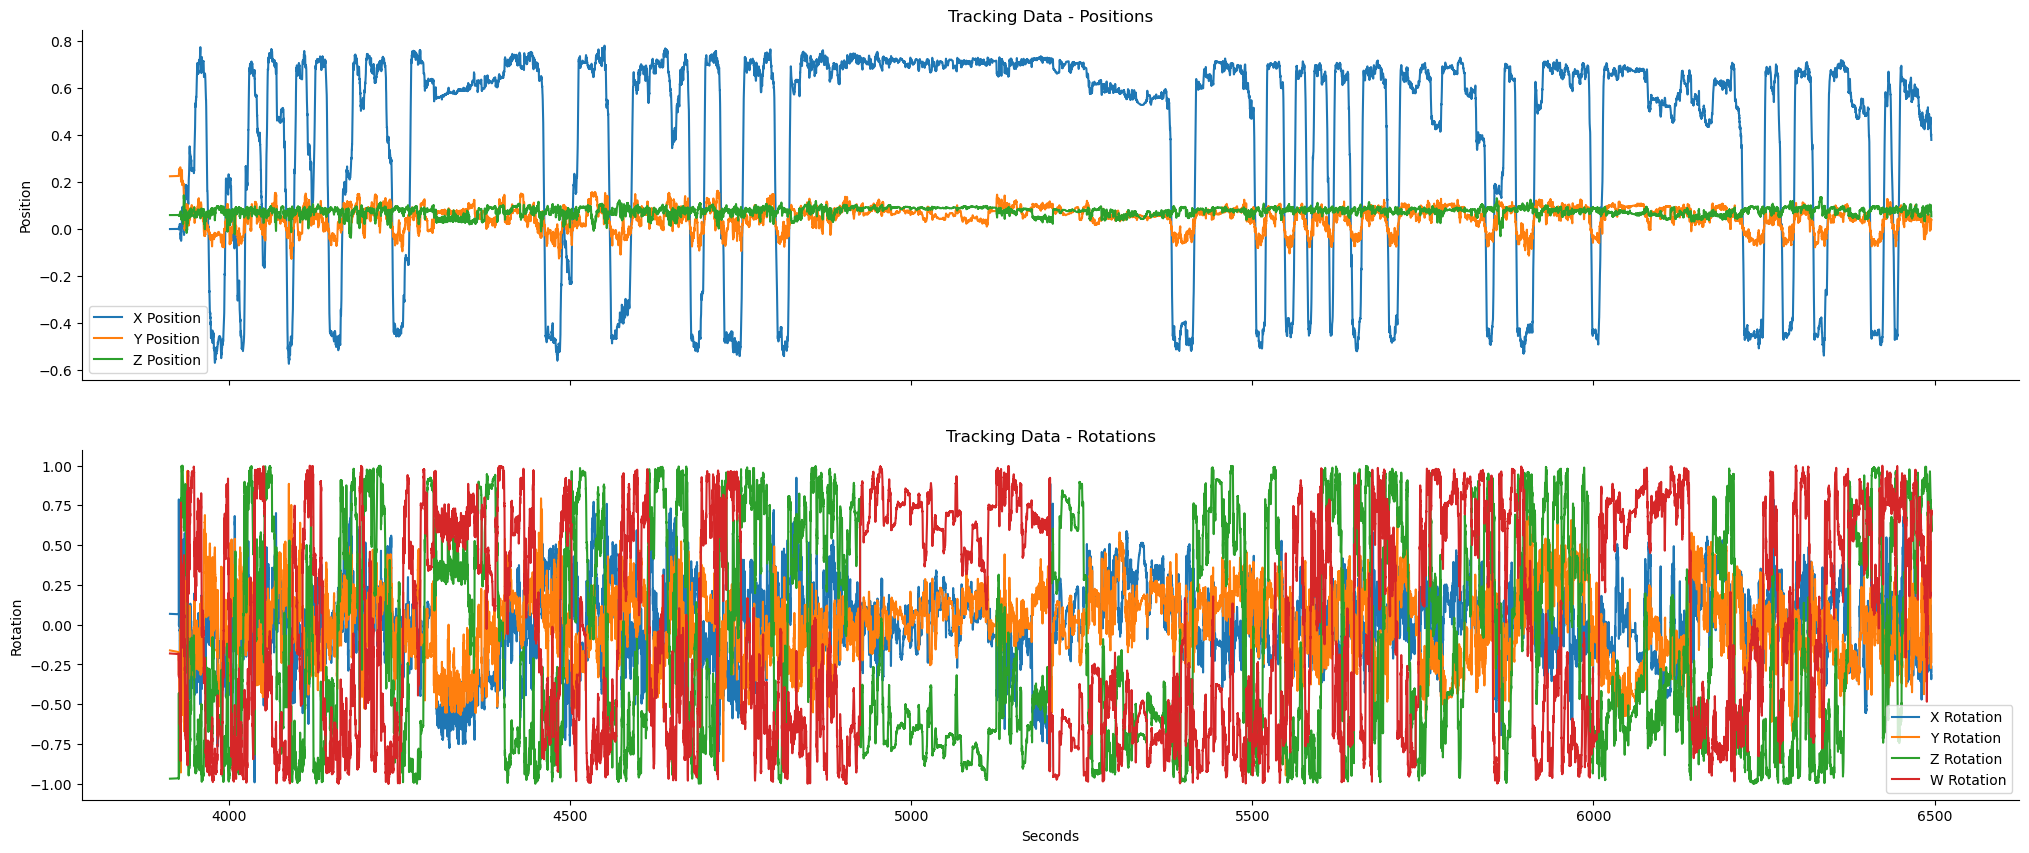

In [5]:

# Loadding in the TTLs
ttl_file = os.path.join(DATA_DIR, 'preprocessing_output', f'supercat_{SESSION_NAME}', f'{SESSION_NAME}_tcat.obx0.obx.xd_6_12_0.txt')
ttls = np.loadtxt(ttl_file)
print(f"Number of TTLs: {len(ttls)}")

# Loadding in the tracking data
tracking_file = os.path.join(DATA_DIR, "Bilat_R02_20251106_linear_maze_000.csv")
tracking_data = np.genfromtxt(tracking_file, delimiter=",", skip_header=7)
frames = tracking_data[:,0]
print(f'Number of frames: {len(frames)}')


# Sometimes there are a few more frames after the last TTL or more TTLs than frames. We will trim the data to the shortest length.
if len(frames) < len(ttls):
    print(f'Trimming TTLs from {len(ttls)} to {len(frames)}')
    ttls = ttls[:len(frames)]
    tracking_data = tracking_data[:len(frames),:]
elif len(frames) > len(ttls):
    print(f'Trimming frames from {len(frames)} to {len(ttls)}')
    frames = frames[:len(ttls)]
    tracking_data = tracking_data[:len(ttls),:]

# printing the start and end times
print(f'Tracking start time: {ttls[0]:.3f} s, end time: {ttls[-1]:.3f} s, duration: {ttls[-1]-ttls[0]:.3f} s')


# fill missing values or nan with linear interpolation
for i in range(tracking_data.shape[1]):
    col = tracking_data[:,i]
    nans = np.isnan(col)
    if np.any(nans):
        not_nans = ~nans
        interp_func_col = interp1d(frames[not_nans], col[not_nans], bounds_error=False, fill_value="extrapolate")
        col[nans] = interp_func_col(frames[nans])
        tracking_data[:,i] = col

# extract x, y, z positions and rotations
x_rotations = tracking_data[:,2]
y_rotations = tracking_data[:,3]
z_rotations = tracking_data[:,4]
w_rotations = tracking_data[:,5]
x_positions = tracking_data[:,6]
y_positions = tracking_data[:,7]
z_positions = tracking_data[:,8]

# Plotting the tracking data
fig, axs = plt.subplots(2, 1, figsize=(25,10), sharex=True)

sns.lineplot(ax=axs[0], x=ttls, y=x_positions, label='X Position')
sns.lineplot(ax=axs[0], x=ttls, y=y_positions, label='Y Position')
sns.lineplot(ax=axs[0], x=ttls, y=z_positions, label='Z Position')
axs[0].set_ylabel('Position')
axs[0].set_title('Tracking Data - Positions')

sns.lineplot(ax=axs[1], x=ttls, y=x_rotations, label='X Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=y_rotations, label='Y Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=z_rotations, label='Z Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=w_rotations, label='W Rotation')
axs[1].set_xlabel('Seconds')
axs[1].set_ylabel('Rotation')
axs[1].set_title('Tracking Data - Rotations')
sns.despine()
plt.show()


In [6]:
win = np.hanning(int(sampling_rate * 0.5))  # 0.5-sec window
SFT = ShortTimeFFT(win, fs=sampling_rate, scale_to='magnitude', hop=len(win) // 4)
Sx = SFT.stft(channel_data)   # shape: (T, F)
freqs = SFT.f                 # frequency axis

print(freqs.shape)
print(Sx.shape)
print(sampling_rate)


(313,)
(313, 4011)
1250


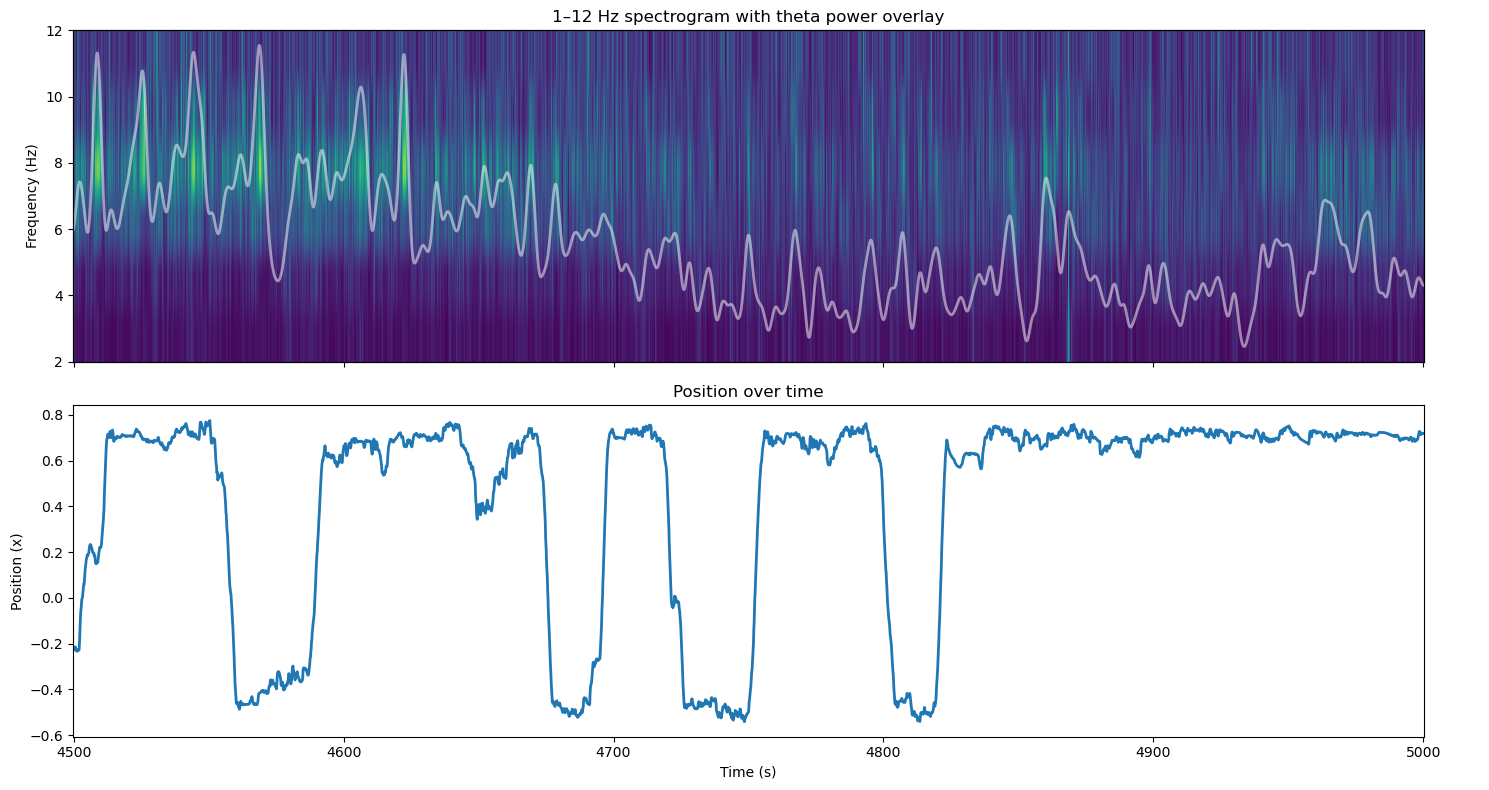

In [10]:
# channel_data: 1D array of LFP
# times: 1D array of time stamps for x_positions (same length as pos)
# pos: x_positions
# Sx: STFT output (freq x time)
# freqs: SFT.f
# SFT: ShortTimeFFT instance

N = channel_data.shape[0]

# --- Select 1–12 Hz ---
fmin, fmax = 1, 12
freq_mask = (freqs >= fmin) & (freqs <= fmax)

Sx_sel = Sx[freq_mask, :]               # (n_sel_freqs, n_time_windows)
freqs_sel = freqs[freq_mask]

# --- Time extent for STFT ---
t_lo, t_hi, _, _ = SFT.extent(N)        # time range from ShortTimeFFT
t_lo = t_lo + START
t_hi = t_hi + START
stft_times = START + SFT.t(N)    # shape: (Sx.shape[1],)

# --- Interpolate position onto STFT time grid ---
pos = x_positions


# But if TTL times and LFP timebase already share the same origin, just use ttls directly:
pos_interp_func = interp1d(ttls, pos, bounds_error=False, fill_value="extrapolate")
pos_stft = pos_interp_func(stft_times)
# --- 1/f correction (multiply by f) ---
Sx_corrected = np.abs(Sx_sel) * freqs_sel[:, np.newaxis]

# --- Mean theta power (6–10 Hz) ---
theta_mask = (freqs_sel >= 6) & (freqs_sel <= 10)
theta_power = Sx_corrected[theta_mask, :].mean(axis=0)   # shape: (n_time_windows,)

# smooth theta power with a Gaussian filter
theta_power = gaussian_filter1d(theta_power, sigma=10)

# ===== PLOTTING =====

fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# --- Top: spectrogram + theta power overlay ---
ax_spec = axs[0]
im = ax_spec.imshow(
    Sx_corrected,
    origin="lower",
    aspect="auto",
    extent=(t_lo, t_hi, freqs_sel[0], freqs_sel[-1]),
    cmap="viridis",
)
ax_spec.set_ylabel("Frequency (Hz)")
ax_spec.set_title("1–12 Hz spectrogram with theta power overlay")

# Colorbar for spectrogram
#cbar = fig.colorbar(im, ax=ax_spec)
#cbar.set_label("1/f-corrected magnitude")

# Theta power overlay (second y-axis)
ax_theta = ax_spec.twinx()
ax_theta.plot(stft_times, theta_power, color="w", linewidth=2, alpha=0.5)
ax_theta.set_ylabel("Theta power (6–10 Hz, a.u.)", color="w")
ax_theta.tick_params(axis="y", colors="w")

# --- Bottom: position vs time ---
ax_pos = axs[1]
ax_pos.plot(stft_times, pos_stft, linewidth=2)
ax_pos.set_ylabel("Position (x)")
ax_pos.set_xlabel("Time (s)")
ax_pos.set_title("Position over time")

plt.tight_layout()
plt.show()

